## Introduction

The goal of this notebook is to train the exact same network as the one used for distillation on the MNIST dataset. Nothing realted to dataset distillation will be implement here, but it will provide a good baseline to compare to.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision
import torch.nn.functional as F

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

In [4]:
dataset_train = torchvision.datasets.MNIST("./",train = True, download=True, transform=transform)
dataset_test = torchvision.datasets.MNIST("./",train = False, download=True, transform=transform)

In [5]:
class TwoLayerMLP(nn.Module):

    def __init__(self):
        super(TwoLayerMLP, self).__init__()

        self.lin1 = nn.Linear(28*28, 128)
        self.lin2 = nn.Linear(128, 10)
    
    def forward(self, x):

        B, C, H, W = x.shape
        
        x = x.view(B, -1)
        
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

In [6]:
model = TwoLayerMLP()

param_count = sum([p.numel() for p in model.parameters()])

print(f"Model has : {param_count/1e6} M params" )

Model has : 0.10177 M params


In [7]:
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=1024, shuffle=True)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=1024, shuffle=True)

In [9]:
def training_loop_data(n_data_points, n_epochs, learning_rate, val_freq): 
    #Since we want to compare random selection and dataset distillation, we should be able to specify how much data we want.
    dataset_train = torchvision.datasets.MNIST("./",train = True, download=True, transform=transform)
    dataset_test = torchvision.datasets.MNIST("./",train = False, download=True, transform=transform)
    if n_data_points == 10: #handpicking to have each class represented
        idx = torch.tensor([0, 1, 2, 3, 4, 5, 7, 13, 15, 17])

    else:
        idx = torch.randint(low = 0, high = len(dataset_train), size = (n_data_points,))

    dataset_train = torch.utils.data.Subset(dataset_train, idx)

    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=1024, shuffle=True)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=1024, shuffle=True)

    model = TwoLayerMLP()
    optimizer = torch.optim.AdamW(params = model.parameters(), lr = learning_rate)
    criterion = nn.CrossEntropyLoss()

    acc_list = []

    for epoch in range(n_epochs):
        model.train()
        for i, (data, labels) in enumerate(dataloader_train):

            optimizer.zero_grad()

            output = model(data)

            loss = criterion(output, labels)

            loss.backward()
            optimizer.step()
        
        if epoch%val_freq == 0:
            model.eval()
            with torch.no_grad() :
                accuracy = 0.0
                for i, (data, labels) in enumerate(dataloader_test):

                    output = model(data)

                    accuracy += (torch.argmax(output, dim = -1) == labels).sum()
            
            accuracy/=10000

            acc_list.append(accuracy.item())
            print(f"Epoch : {epoch}, accuracy : {accuracy}")


    return acc_list, model

In [ ]:
acc_list, model = training_loop_data(10, 200, 1e-3, 10) # 10 random data points (all classes represented)

Epoch : 0, accuracy : 0.16869999468326569
Epoch : 10, accuracy : 0.4846000075340271
Epoch : 20, accuracy : 0.5022000074386597
Epoch : 30, accuracy : 0.5044000148773193
Epoch : 40, accuracy : 0.5030999779701233
Epoch : 50, accuracy : 0.5034000277519226
Epoch : 60, accuracy : 0.5041999816894531
Epoch : 70, accuracy : 0.5042999982833862
Epoch : 80, accuracy : 0.5038999915122986
Epoch : 90, accuracy : 0.5040000081062317
Epoch : 100, accuracy : 0.5044999718666077
Epoch : 110, accuracy : 0.5042999982833862
Epoch : 120, accuracy : 0.5041999816894531
Epoch : 130, accuracy : 0.5031999945640564
Epoch : 140, accuracy : 0.5030999779701233
Epoch : 150, accuracy : 0.5024999976158142
Epoch : 160, accuracy : 0.5023000240325928
Epoch : 170, accuracy : 0.5020999908447266
Epoch : 180, accuracy : 0.5022000074386597
Epoch : 190, accuracy : 0.5019000172615051


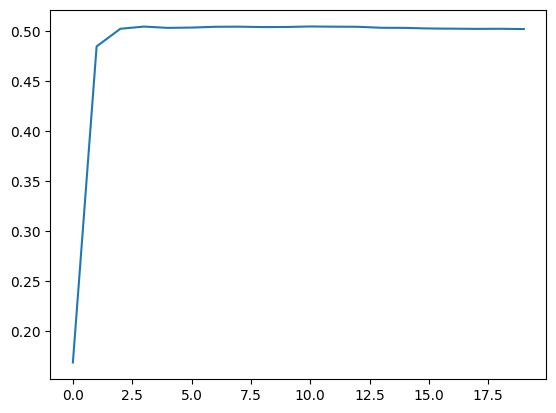

In [56]:
plt.plot(acc_list)
plt.show()

In [ ]:
acc_list, model = training_loop_data(200, 100, 1e-3, 5) # 200 random data points

Epoch : 0, accuracy : 0.26330000162124634
Epoch : 5, accuracy : 0.5034999847412109
Epoch : 10, accuracy : 0.6146000027656555
Epoch : 15, accuracy : 0.7039999961853027
Epoch : 20, accuracy : 0.755299985408783
Epoch : 25, accuracy : 0.7738999724388123
Epoch : 30, accuracy : 0.7843999862670898
Epoch : 35, accuracy : 0.7936000227928162
Epoch : 40, accuracy : 0.8003000020980835
Epoch : 45, accuracy : 0.8036999702453613
Epoch : 50, accuracy : 0.8033000230789185
Epoch : 55, accuracy : 0.8015000224113464
Epoch : 60, accuracy : 0.8007000088691711
Epoch : 65, accuracy : 0.8004999756813049
Epoch : 70, accuracy : 0.8004000186920166
Epoch : 75, accuracy : 0.8004000186920166
Epoch : 80, accuracy : 0.7997000217437744
Epoch : 85, accuracy : 0.800000011920929
Epoch : 90, accuracy : 0.800000011920929
Epoch : 95, accuracy : 0.8001999855041504


In [ ]:
acc_list, model = training_loop_data(1000, 100, 1e-3, 5) # 1000 random data points

Epoch : 0, accuracy : 0.38530001044273376
Epoch : 5, accuracy : 0.6621999740600586
Epoch : 10, accuracy : 0.7196000218391418
Epoch : 15, accuracy : 0.7696999907493591
Epoch : 20, accuracy : 0.8077999949455261
Epoch : 25, accuracy : 0.8242999911308289
Epoch : 30, accuracy : 0.8393999934196472
Epoch : 35, accuracy : 0.8543000221252441
Epoch : 40, accuracy : 0.8650000095367432
Epoch : 45, accuracy : 0.871999979019165
Epoch : 50, accuracy : 0.8780999779701233
Epoch : 55, accuracy : 0.8827999830245972
Epoch : 60, accuracy : 0.8855000138282776
Epoch : 65, accuracy : 0.8870000243186951
Epoch : 70, accuracy : 0.8901000022888184
Epoch : 75, accuracy : 0.8920000195503235
Epoch : 80, accuracy : 0.8927000164985657
Epoch : 85, accuracy : 0.8924999833106995
Epoch : 90, accuracy : 0.8937000036239624
Epoch : 95, accuracy : 0.8934999704360962


In [ ]:
acc_list, model = training_loop_data(10000, 100, 1e-3, 5) # 10000 random data points

Epoch : 0, accuracy : 0.7448999881744385
Epoch : 5, accuracy : 0.890999972820282
Epoch : 10, accuracy : 0.9121999740600586
Epoch : 15, accuracy : 0.9204000234603882
Epoch : 20, accuracy : 0.9258999824523926
Epoch : 25, accuracy : 0.9296000003814697
Epoch : 30, accuracy : 0.9319999814033508
Epoch : 35, accuracy : 0.9354000091552734
Epoch : 40, accuracy : 0.9377999901771545
Epoch : 45, accuracy : 0.9405999779701233
Epoch : 50, accuracy : 0.9413999915122986
Epoch : 55, accuracy : 0.9424999952316284
Epoch : 60, accuracy : 0.9434999823570251
Epoch : 65, accuracy : 0.9449999928474426
Epoch : 70, accuracy : 0.9462000131607056
Epoch : 75, accuracy : 0.9459999799728394
Epoch : 80, accuracy : 0.9473000168800354
Epoch : 85, accuracy : 0.9470999836921692
Epoch : 90, accuracy : 0.9466000199317932
Epoch : 95, accuracy : 0.9480000138282776


In [10]:
acc_list, model = training_loop_data(60000, 50, 1e-3, 5) # On the whole dataset

Epoch : 0, accuracy : 0.8938999772071838
Epoch : 5, accuracy : 0.9440000057220459
Epoch : 10, accuracy : 0.9581000208854675
Epoch : 15, accuracy : 0.9656999707221985
Epoch : 20, accuracy : 0.9690999984741211
Epoch : 25, accuracy : 0.9707000255584717
Epoch : 30, accuracy : 0.9717000126838684
Epoch : 35, accuracy : 0.972599983215332
Epoch : 40, accuracy : 0.9729999899864197
Epoch : 45, accuracy : 0.9726999998092651
